In [70]:
pip install --upgrade keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [71]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [72]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [73]:
pip install jax jaxlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [74]:
import numpy as np
import matplotlib.pyplot as plt


In [75]:
pip install tensorflow-datasets


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [76]:
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.decomposition import PCA

In [77]:
import keras as tf
import keras
model = keras.Sequential()

# -----------------------
# Data 
# -----------------------
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()

In [78]:
x_train_img.dtype, y_train.dtype, x_test_img.dtype, y_test.dtype

(dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'))

In [79]:
# Normalize images in [0,1]
x_train_img = x_train_img.astype(np.float32) / 255.0   # (N,28,28)
x_test_img  = x_test_img.astype(np.float32)  / 255.0

y_train = y_train.astype(np.int64)
y_test  = y_test.astype(np.int64)

In [80]:
# Flattened versions for NumPy training
x_train = x_train_img.reshape(-1, 784)  # (N,784)
x_test  = x_test_img.reshape(-1, 784)



In the below section, I'm focusing on data exploratory analysis where I'll try to understand the data.

In the below boxplot, I've focused on mean intensity of each digits. Outliers represents the dark images.

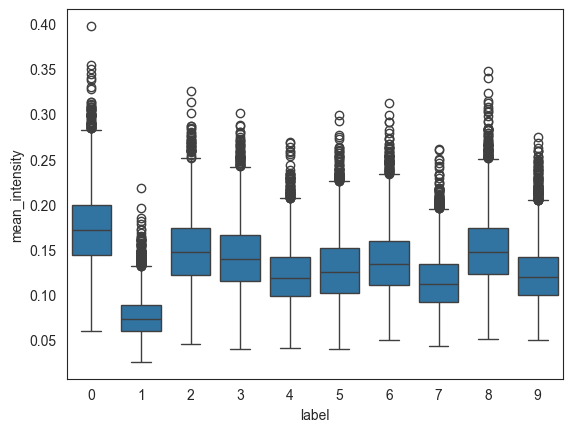

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Outliers per digits:
df = pd.DataFrame({
    'mean_intensity': x_train.mean(axis=1),
    'label': y_train
})

sns.boxplot(data=df, x='label', y='mean_intensity')
plt.show()

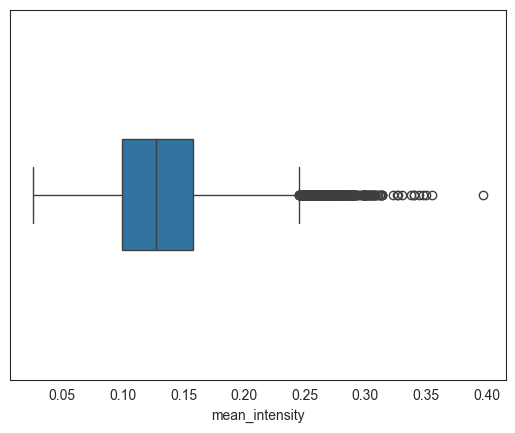

In [82]:
#Check the outliers from the training set using boxplot
# Compute mean pixel value per image
#very dark images (possible outliers)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean pixel value per image
mean_intensity = x_train.mean(axis=1)  # shape (N,)

df = pd.DataFrame({'mean_intensity': mean_intensity})

sns.boxplot(data=df, x='mean_intensity', width=0.3)
plt.show()

In [83]:
for column in df.select_dtypes(include=np.number).columns:
    q25 = df[column].quantile(0.25)
    q75 = df[column].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {outliers.shape[0]} outliers")

mean_intensity: 610 outliers


In [84]:
df.columns

Index(['mean_intensity'], dtype='object')

In [85]:
#count missing values in the dataset
#keras does not have missing values in the dataset, but we can check for missing values in the dataframe
missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")

Missing values:
mean_intensity    0
dtype: int64


In [86]:
pca = PCA(n_components=1)
pc1 = pca.fit_transform(x_train)

df = pd.DataFrame({'PC1': pc1[:, 0]})

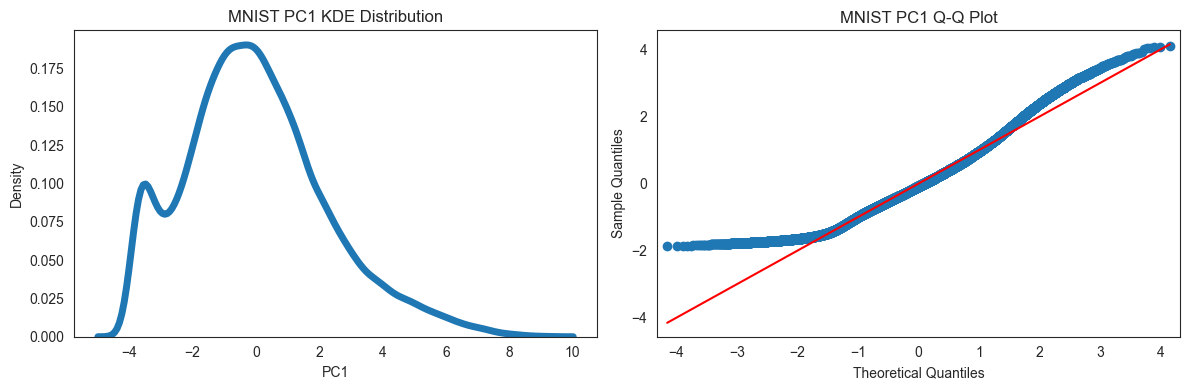

In [87]:
sns.set_style("white")

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# KDE plot
sns.kdeplot(data=df, x="PC1", linewidth=5, ax=ax1)
ax1.set_title("MNIST PC1 KDE Distribution")

# Q-Q plot
sm.qqplot(df['PC1'], line='s', ax=ax2, dist=stats.norm, fit=True)
ax2.set_title("MNIST PC1 Q-Q Plot")

plt.tight_layout()
plt.show()

In [88]:
# -----------------------
# Data 
# -----------------------
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()
# Normalize images in [0,1]
x_train_img = x_train_img.astype(np.float32) / 255.0   # (N,28,28)
x_test_img  = x_test_img.astype(np.float32)  / 255.0

y_train = y_train.astype(np.int64)
y_test  = y_test.astype(np.int64)
# Flattened versions for NumPy training
x_train = x_train_img.reshape(-1, 784)  # (N,784)
x_test  = x_test_img.reshape(-1, 784)

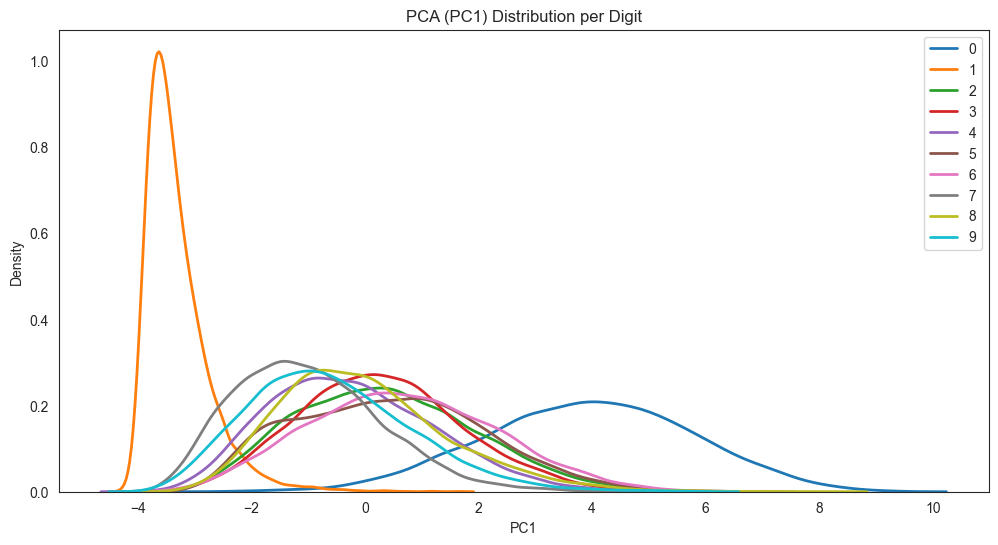

In [89]:
# PCA and KDE plot per digit: we're checking the distribution of the first principal component (PC1) for each digit class to see if there are
#  any differences in the distributions across the classes. This can help us understand if PCA is capturing meaningful variance 
# related to the digit classes.
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=1)
pc1 = pca.fit_transform(x_train)

df = pd.DataFrame({
    'PC1': pc1[:, 0],
    'label': y_train
})

sns.set_style("white")

plt.figure(figsize=(12,6))

for digit in range(10):
    sns.kdeplot(
        data=df[df['label'] == digit],
        x='PC1',
        label=str(digit),
        linewidth=2
    )

plt.title("PCA (PC1) Distribution per Digit")
plt.legend()
plt.show()

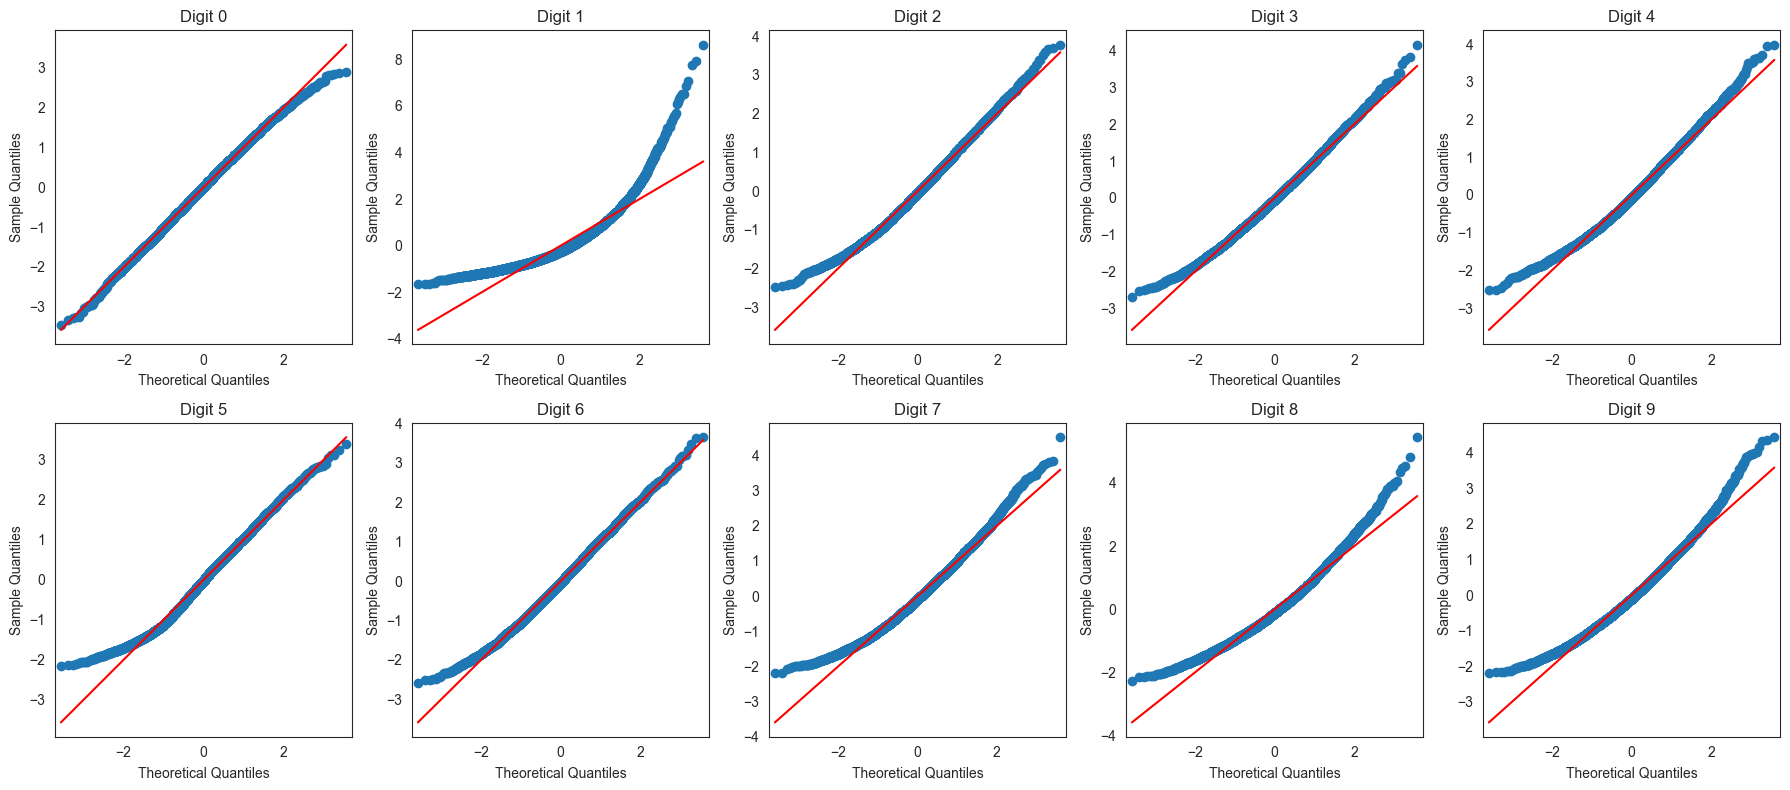

In [90]:
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for digit in range(10):
    sm.qqplot(
        df[df['label'] == digit]['PC1'],
        line='s',
        ax=axes[digit],
        dist=stats.norm,
        fit=True
    )
    axes[digit].set_title(f"Digit {digit}")

plt.tight_layout()
plt.show()

None of the digits are evenly distributed.
MNIST is manifold-structured data
Not generated from Gaussian processes
Each digit class has its own latent distribution

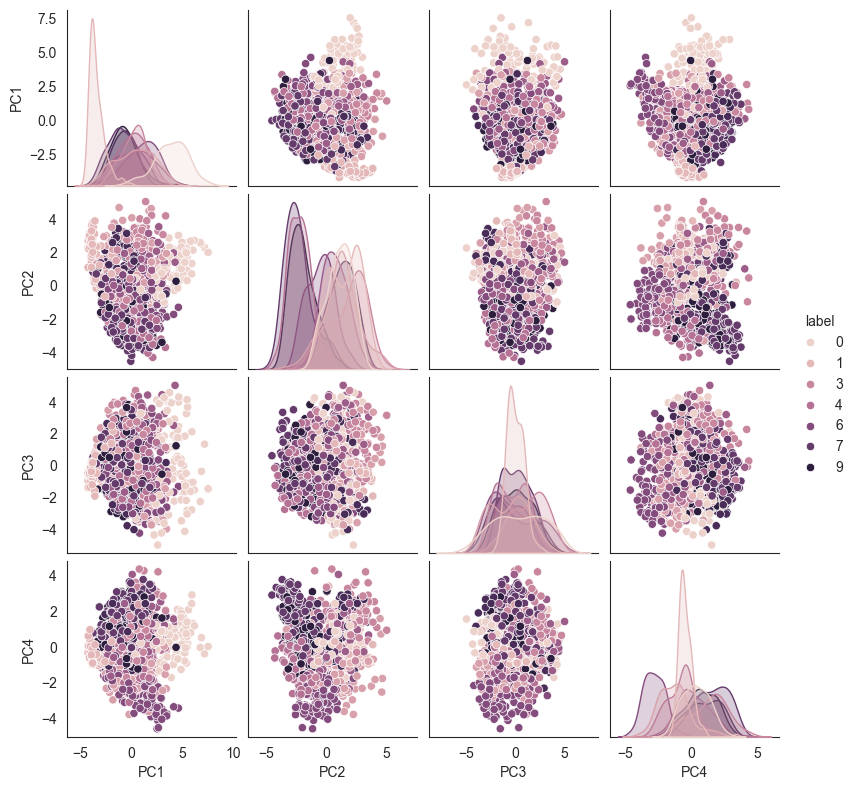

In [91]:
#generate pair plot of the first 10 images in the training set
# Use PCA to reduce dimensionality to 4 features, then create a pairplot colored by labels
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Take a smaller subset (important for speed)
X_subset = x_train[:1000]
y_subset = y_train[:1000]

# Apply PCA → reduce 784 → 4 features
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_subset)

# Create DataFrame
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df['label'] = y_subset

# Pairplot
sns.pairplot(df, hue='label', height=2)
plt.show()

In [92]:
# print shapes of training and test here
print(f"Training data shape: {x_train_img.shape}")
print(f"Test data shape: {x_test_img.shape}")
print(f"Training labels shape: {x_train.shape}")
print(f"Test labels shape: {x_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Unique Labels:{np.unique(y_test)}")
print(f"Unique Labels:{np.unique(y_train)}")
print(f"Number of unique data points: {len(np.unique(x_train_img))}")
print(f"Number of unique data points: {len(np.unique(x_test_img))}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000, 784)
Test labels shape: (10000, 784)
Training labels shape: (60000,)
Test labels shape: (10000,)
Unique Labels:[0 1 2 3 4 5 6 7 8 9]
Unique Labels:[0 1 2 3 4 5 6 7 8 9]
Number of unique data points: 256
Number of unique data points: 256


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, precision_recall_fscore_support)

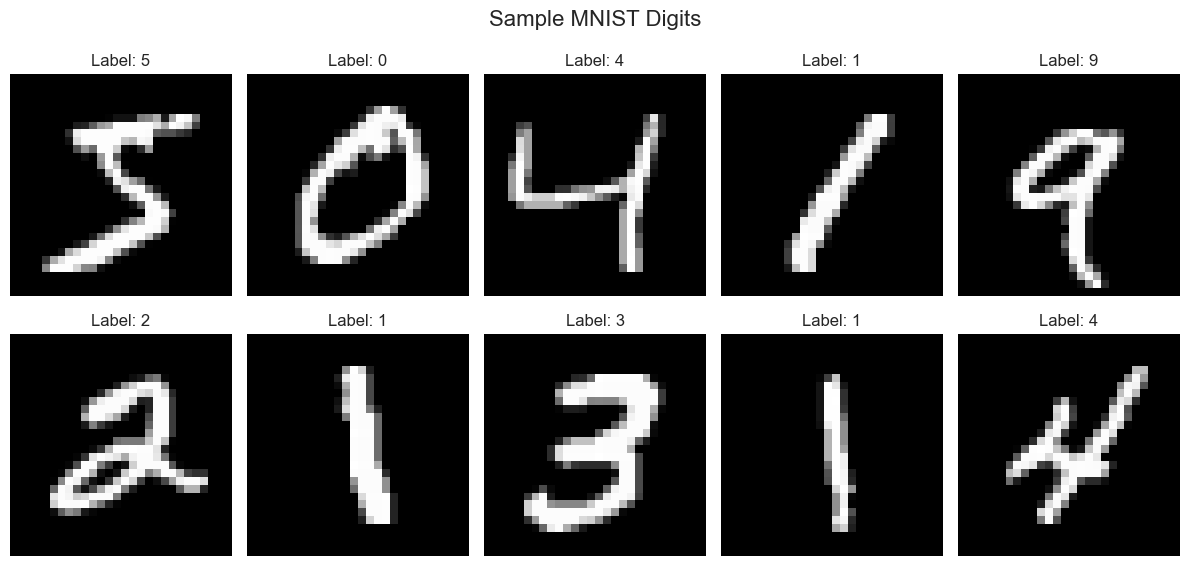

In [95]:
def visualize_samples(x_train_img, y_train, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Sample MNIST Digits', fontsize=16)
    for i in range(num_samples):
        row = i // 5
        col = i % 5
         # Reshape the flattened image back to 28x28
        digit_image = x_train_img[i].reshape(28,28)
        axes[row, col].imshow(digit_image, cmap='gray')
        axes[row, col].set_title(f'Label: {y_train[i]}')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
# Load the data
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()
# Visualize some samples
visualize_samples(x_train_img,y_train)

In [96]:
pip install pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [97]:
#check for null values
print("Checking for null values in training data:")
print(f"Null values in X_train: {np.isnan(x_train_img).sum()}")
print(f"Null values in y_train: {np.isnan(y_train).sum()}") 

Checking for null values in training data:
Null values in X_train: 0
Null values in y_train: 0


In [99]:
#implementing the HOG feature extraction for the MNIST dataset
from skimage.feature import hog
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
# 1. Load and Normalize Data
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1]
x_train_img = x_train_img.astype('float32') / 255.0
x_test_img = x_test_img.astype('float32') / 255.0

# Flattened versions for NumPy training
x_train = x_train_img.reshape(-1, 784)  # (N,784)
x_test  = x_test_img.reshape(-1, 784)





In [101]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [102]:
rmse=[]   


print(x_train.shape)
print(x_test.shape)

# C is the penalty parameter. Lower C = softer margin (more regularization)
svm_model = LinearSVC(C=1, loss='hinge', dual='auto', max_iter=10000)
# Now fit the model using the flattened data
svm_model.fit(x_train, y_train)
#implement rbf kernel SVM
rbf_svm_model = SVC(kernel='rbf', C=1, gamma='scale')
rbf_svm_model.fit(x_train, y_train)


#Evaluate SVM
svm_pred = svm_model.predict(x_test)
rbf_pred = rbf_svm_model.predict(x_test)
rmse.append(mean_squared_error(y_test, svm_pred))
rmse.append(mean_squared_error(y_test, rbf_pred))
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"RBF SVM Accuracy: {accuracy_score(y_test, rbf_pred):.4f}")
print(f"Classification Report for Linear SVM:")
print(classification_report(y_test, svm_pred))
print(f"Mean Squared Error for Linear SVM:", mean_squared_error(y_test, svm_pred))
print(f"Classification Report for RBF SVM:")
print(classification_report(y_test, rbf_pred))      
print("Mean Squared Error for RBF SVM:", mean_squared_error(y_test, rbf_pred))



(60000, 784)
(10000, 784)


C:\Users\yashs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM Accuracy: 0.9216
RBF SVM Accuracy: 0.9792
Classification Report for Linear SVM:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.91      0.91      0.91      1010
           4       0.91      0.93      0.92       982
           5       0.89      0.87      0.88       892
           6       0.93      0.95      0.94       958
           7       0.93      0.93      0.93      1028
           8       0.88      0.87      0.87       974
           9       0.91      0.89      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Mean Squared Error for Linear SVM: 1.3698
Classification Report for RBF SVM:
              precision    recall  f1-score   support

           0       0.98  

In [103]:
cm_svm = confusion_matrix(y_test, svm_pred)
cm_rbf = confusion_matrix(y_test, rbf_pred)

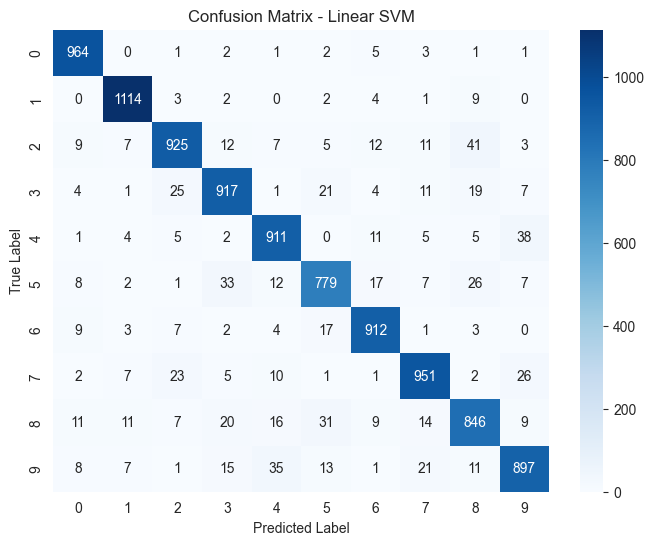

In [104]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

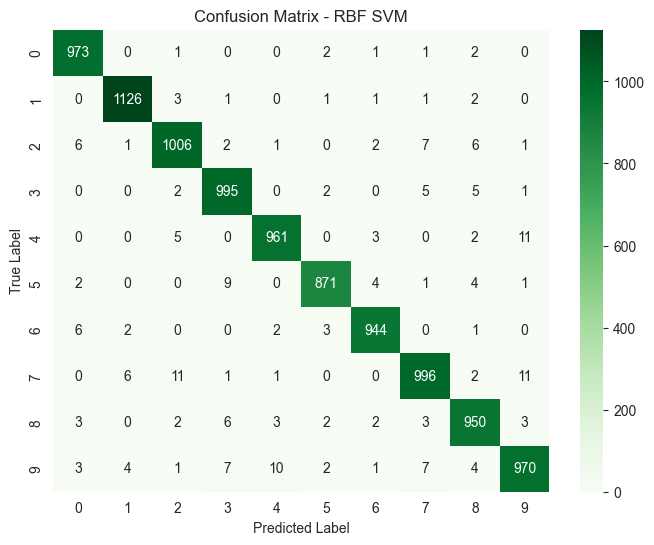

In [105]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [106]:
#implementing logistic regression with HOG features
rmse =[]
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', multi_class='multinomial')


log_reg_model.fit(x_train, y_train)

#Evaluate Logistic Regression
log_reg_pred = log_reg_model.predict(x_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_pred):.4f}")
print("Classification Report for Logistic Regression:") 
print(classification_report(y_test, log_reg_pred))
print("Mean Squared Error for Logistic Regression:", mean_squared_error(y_test, log_reg_pred))
rmse.append(mean_squared_error(y_test, log_reg_pred))
print("RMSE values for all models:", rmse)


C:\Users\yashs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.9259
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

Mean Squared Error for Logistic Regression: 1.2482
RMSE values for all models: [1.2482]


In [36]:
cm_log_reg = confusion_matrix(y_test, log_reg_pred)

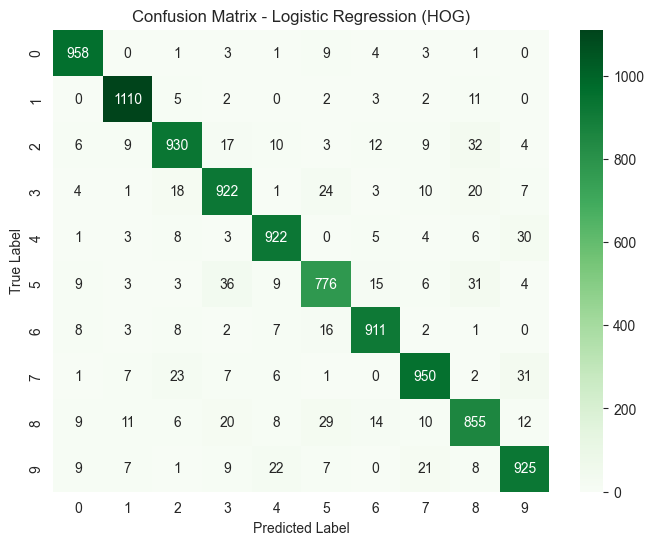

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Logistic Regression (HOG)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [38]:
#one-hot
#def one_hot(y, num_classes=10):
#    Y = np.zeros((len(y), num_classes))
#    Y[np.arange(len(y)), y] = 1
#    return Y


#Y_train = one_hot(y_train_combined)
#Y_test = one_hot(y_test)

from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10) 
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")
print(f"X_train shape: {x_train.shape}")
print(f"X_test shape: {x_test.shape}")

Y_train shape: (60000, 10)
Y_test shape: (10000, 10)
X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [108]:


import matplotlib.pyplot as plt
import keras
from keras import layers
import numpy as np

# 1. Setup labels and parameters
Y_train_int = np.argmax(Y_train, axis=1)
Y_test_int = np.argmax(Y_test, axis=1)


num_features = x_train.shape[1]
print(f"Number of features: {num_features}")
print(f"Unique labels in training set: {np.unique(Y_train_int)}")
print(f"Unique labels in test set: {np.unique(Y_test_int)}")
def train_model(activation):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(
    128, 
    activation=activation,
    kernel_initializer='he_uniform',
    bias_initializer='zeros'
),
layers.Dense(
    64, 
    activation=activation,
    kernel_initializer='he_uniform',
    bias_initializer='zeros'
),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        x_train, Y_train_int,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )
    
    test_loss, test_acc = model.evaluate(x_test, Y_test_int, verbose=0)
    
    return history, test_acc, test_loss





Number of features: 784
Unique labels in training set: [0 1 2 3 4 5 6 7 8 9]
Unique labels in test set: [0 1 2 3 4 5 6 7 8 9]


In [109]:
history_relu, acc_relu, loss_relu = train_model('relu')
history_sigmoid, acc_sigmoid, loss_sigmoid = train_model('sigmoid')
history_tanh, acc_tanh, loss_tanh = train_model('tanh')
print(f"ReLU Test Accuracy: {acc_relu:.4f}, Test Loss: {loss_relu:.4f}")
print(f"Sigmoid Test Accuracy: {acc_sigmoid:.4f}, Test Loss: {loss_sigmoid:.4f}")
print(f"Tanh Test Accuracy: {acc_tanh:.4f}, Test Loss: {loss_tanh:.4f}")


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9254 - loss: 0.2508 - val_accuracy: 0.9630 - val_loss: 0.1235
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9679 - loss: 0.1050 - val_accuracy: 0.9737 - val_loss: 0.0887
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9775 - loss: 0.0722 - val_accuracy: 0.9740 - val_loss: 0.0910
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9825 - loss: 0.0548 - val_accuracy: 0.9802 - val_loss: 0.0742
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9865 - loss: 0.0420 - val_accuracy: 0.9768 - val_loss: 0.0774
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9886 - loss: 0.0356 - val_accuracy: 0.9783 - val_loss: 0.0850
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9905 - loss: 0.0282 - val_accuracy: 0.9780 - val_loss: 0.0816
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9913 - loss: 0.0255 - 

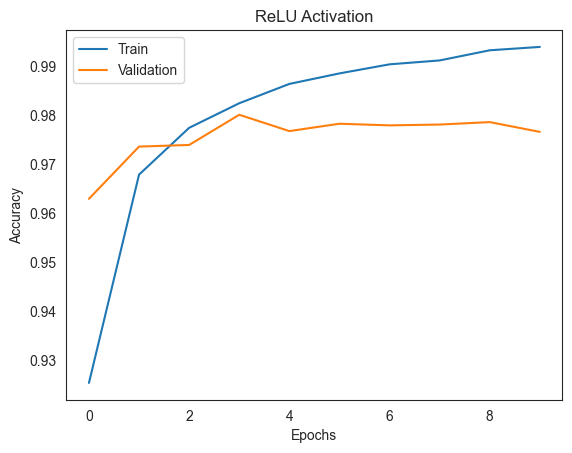

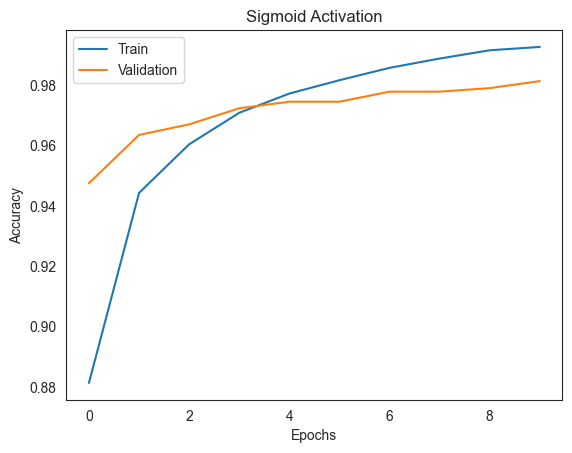

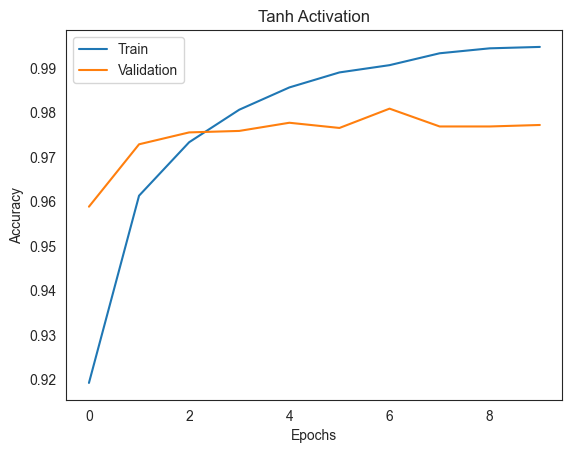

In [112]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
plot_history(history_relu, "ReLU Activation")
plot_history(history_sigmoid, "Sigmoid Activation") 
plot_history(history_tanh, "Tanh Activation")

In [113]:
print("ReLU    -> Acc:", acc_relu, "Loss:", loss_relu)
print("Sigmoid -> Acc:", acc_sigmoid, "Loss:", loss_sigmoid)
print("Tanh    -> Acc:", acc_tanh, "Loss:", loss_tanh)


ReLU    -> Acc: 0.9771999716758728 Loss: 0.09624015539884567
Sigmoid -> Acc: 0.9779000282287598 Loss: 0.07147858291864395
Tanh    -> Acc: 0.9735999703407288 Loss: 0.10158530622720718


In [114]:
#BATCH wise loss and norm

import tensorflow as tf

#clean comparison with keras optimizers

optimizers = {
    "GD": keras.optimizers.SGD(learning_rate=0.1), #for better convergence, we can use a 
    #higher learning rate for GD since it uses the full batch
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "AGD": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
}

results = {}

for name, optimizer in optimizers.items():
    
    print(f"\nTraining with {name}")
    
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(64, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Batch size difference
    if name == "GD":
        batch_size = len(x_train)  # Full batch
    else:
        batch_size = 32
    
    history = model.fit(
        x_train,
        np.argmax(Y_train, axis=1),
        epochs=10,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(
        x_test,
        np.argmax(Y_test, axis=1),
        verbose=0
    )

    
    results[name] = {
        "history": history.history,
        "test_acc": test_acc}

    print(f"{name} Accuracy: {test_acc:.4f}")





Training with GD
GD Accuracy: 0.5498

Training with SGD
SGD Accuracy: 0.9656

Training with AGD
AGD Accuracy: 0.9756


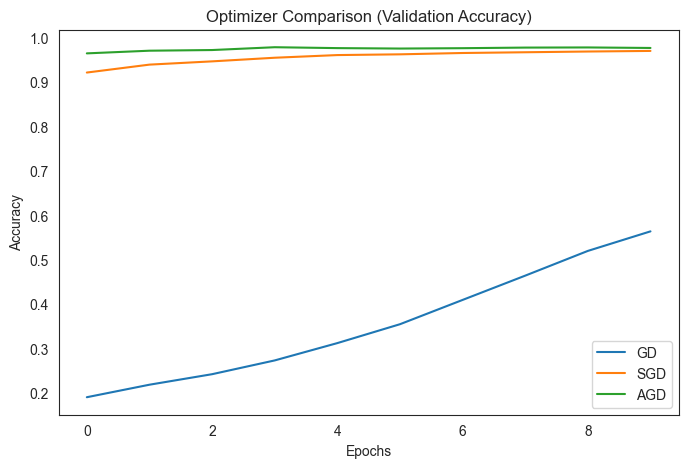

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for name in results:
    plt.plot(results[name]['history']['val_accuracy'], label=name)

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



In [116]:
import numpy as np
import numpy.linalg as la

def gd_onedot(X, Y, W0, epsilon=1e-6, max_iter=500):
    """
    Gradient Descent for min ||XW - Y||^2
    X: (m, n)
    Y: (m, k)  -> one-hot labels
    W0: (n, k) initial weights
    """
    
    W = W0.copy()
    
    # initial gradient
    grad = 2 * X.T @ (X @ W - Y)
    grad_norms = []
    print(f"Initial ||grad||: {la.norm(grad):.4e}")
    
    losses = []
    
    iter_count = 0
      # Lipschitz constant
    L = 2 * la.norm(X, 2)**2
    alpha = 2 / L  # Step size based on Lipschitz constant
    while la.norm(grad) > epsilon and iter_count < max_iter:
        
      
        
        # gradient update
        W = W - alpha * grad
        
        # recompute gradient
        grad = 2 * X.T @ (X @ W - Y)
        current_norm = la.norm(grad)

        
        # compute loss
        loss = la.norm(X @ W - Y)**2
        losses.append(loss)

        #compute gradient norm
        grad_norms.append(current_norm)

        print(f"Iter {iter_count}: Loss = {loss:.4f}, ||grad|| = {la.norm(grad):.4e}, ||grad_norm|| = {la.norm(grad):.4e} ")
        
        
        iter_count += 1

    return W, losses, current_norm


In [117]:
W0 = np.zeros((x_train.shape[1], 10))

W, losses, grad_norms = gd_onedot(x_train, Y_train, W0)


Initial ||grad||: 2.5714e+05
Iter 0: Loss = 54031.8585, ||grad|| = 2.4852e+05, ||grad_norm|| = 2.4852e+05 
Iter 1: Loss = 49794.6665, ||grad|| = 2.4260e+05, ||grad_norm|| = 2.4260e+05 
Iter 2: Loss = 46717.7235, ||grad|| = 2.3849e+05, ||grad_norm|| = 2.3849e+05 
Iter 3: Loss = 44430.5074, ||grad|| = 2.3562e+05, ||grad_norm|| = 2.3562e+05 
Iter 4: Loss = 42689.8765, ||grad|| = 2.3359e+05, ||grad_norm|| = 2.3359e+05 
Iter 5: Loss = 41334.3817, ||grad|| = 2.3212e+05, ||grad_norm|| = 2.3212e+05 
Iter 6: Loss = 40255.4222, ||grad|| = 2.3105e+05, ||grad_norm|| = 2.3105e+05 
Iter 7: Loss = 39378.9131, ||grad|| = 2.3025e+05, ||grad_norm|| = 2.3025e+05 
Iter 8: Loss = 38653.5499, ||grad|| = 2.2964e+05, ||grad_norm|| = 2.2964e+05 
Iter 9: Loss = 38043.2353, ||grad|| = 2.2916e+05, ||grad_norm|| = 2.2916e+05 
Iter 10: Loss = 37522.1491, ||grad|| = 2.2879e+05, ||grad_norm|| = 2.2879e+05 
Iter 11: Loss = 37071.5081, ||grad|| = 2.2850e+05, ||grad_norm|| = 2.2850e+05 
Iter 12: Loss = 36677.4148, ||gra

In [118]:
def predict(X, W):
    return np.argmax(X @ W, axis=1)

y_pred = predict(x_test, W)
accuracy = np.mean(y_pred == Y_test_int)
print(f"Test Accuracy: {accuracy * 100:.2f}%")




Test Accuracy: 85.38%


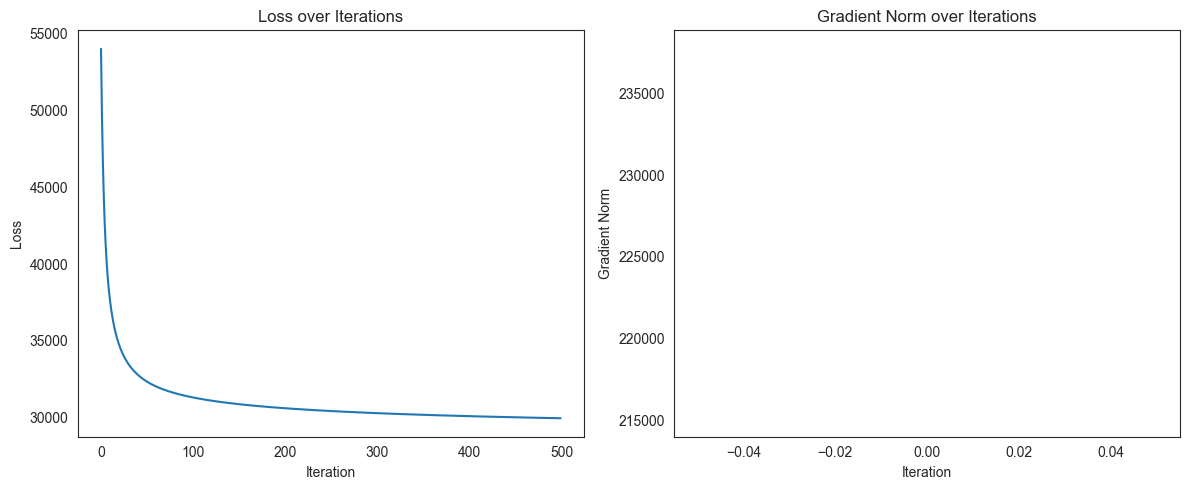

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over Iterations")

# Gradient norm plot
plt.subplot(1, 2, 2)
plt.plot(grad_norms)
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm over Iterations")

plt.tight_layout()
plt.show()


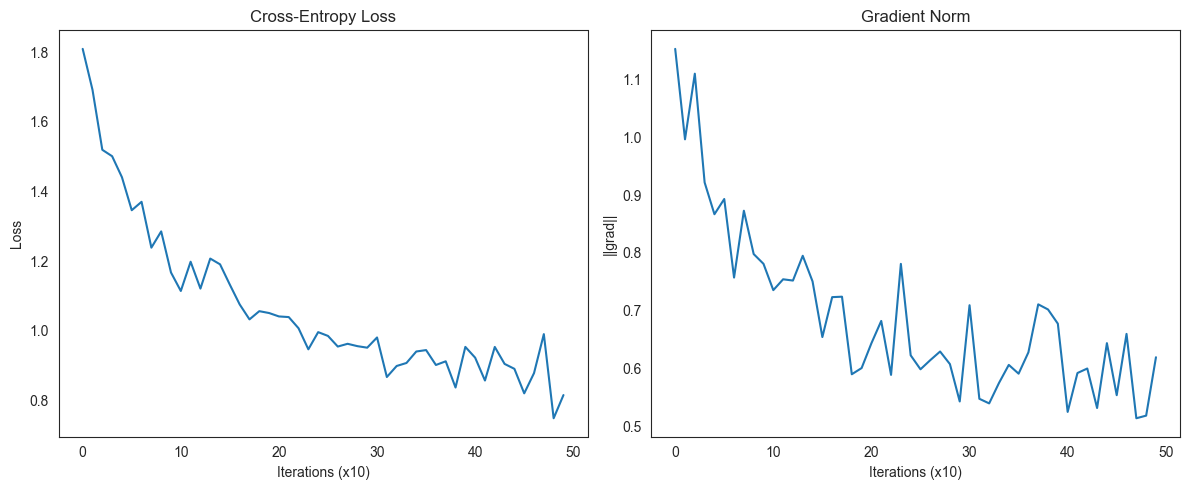

In [120]:

# 2. Initialize Parameters

A = x_train # Input features (N, 784)
n,m = A.shape
b = Y_train  # One-hot labels (N, 10)
np.random.seed(123)
W = np.zeros((m, 10))  # Weights (replacing your x)
maxiter = 500
batch = 128
vec_loss = []
vec_acc = []
vec_grad_norm = []
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
# 3. SGD Loop
for k in range(1, maxiter + 1):
    # Dynamic learning rate (alpha)
    alpha = 0.1 / np.sqrt(k)
    
    # Random mini-batch selection
    idx = np.random.permutation(n)[:batch]
    A_batch = A[idx]
    b_batch = b[idx]

    # Forward pass: Linear combination + Softmax
    logits = A_batch @ W
    predictions = softmax(logits)

    # Compute Gradient: (A^T * (predictions - targets))
    # This is the classification equivalent of your 2 * A.T @ (Ax - b)
    grad = (1 / batch) * A_batch.T @ (predictions - b_batch)
    grad_norm = la.norm(grad)
    

    # Update weights
    W = W - alpha * grad

    # Track Loss (Cross-Entropy) for plotting
    if k % 10 == 0:
        full_preds = softmax(A[idx] @ W)
        loss = -np.mean(np.sum(b_batch * np.log(full_preds + 1e-8), axis=1))
        vec_loss.append(loss)
        vec_grad_norm.append(grad_norm)
        

# 4. Visualize Progress
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(vec_loss)
plt.title("Cross-Entropy Loss")
plt.xlabel("Iterations (x10)")
plt.ylabel("Loss")

# Gradient Norm
plt.subplot(1,2,2)
plt.plot(vec_grad_norm)
plt.title("Gradient Norm")
plt.xlabel("Iterations (x10)")
plt.ylabel("||grad||")

plt.tight_layout()
plt.show()

In [121]:
vec_acc = []
# Track Loss and Accuracy every 10 iterations
if k % 10 == 0:
        # Loss calculation
    loss = -np.mean(np.sum(b_batch * np.log(predictions + 1e-8), axis=1))
    vec_loss.append(loss)
        
    # Accuracy calculation:
    # np.argmax converts [[0, 0, 1...]] -> [2] (the digit label)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(b_batch, axis=1)
    accuracy = np.mean(pred_labels == true_labels)
    print(f"Iteration {k}: Accuracy = {accuracy:.4f}")
    vec_acc.append(accuracy)

# 4. Final Accuracy on Test Data
# Assuming you have x_test_final and Y_test (one-hot)
test_logits = x_test @ W
test_preds = np.argmax(softmax(test_logits), axis=1)
test_true = np.argmax(Y_test, axis=1)
final_test_acc = np.mean(test_preds == test_true) * 100

print(f"Final Test Accuracy: {final_test_acc:.2f}%")

Iteration 500: Accuracy = 0.8750
Final Test Accuracy: 84.37%


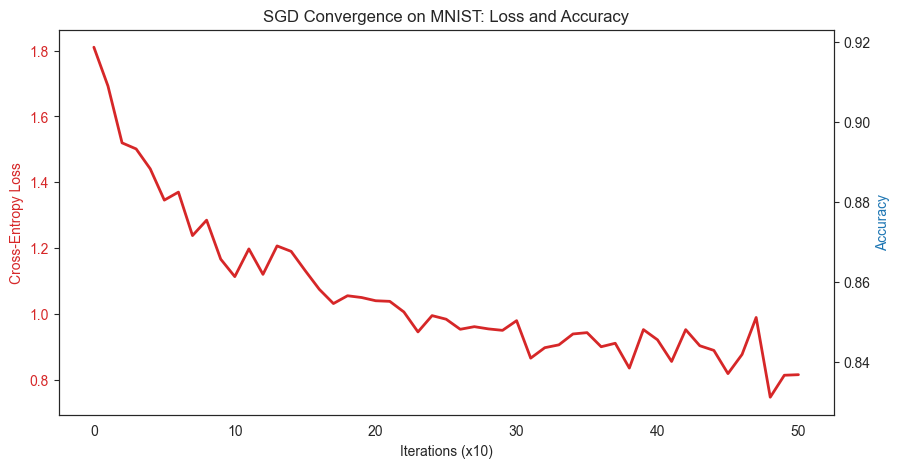

In [122]:

# Creating a second Y-axis for Accuracy
ax2 = ax1.twinx() 

# 4. Visualize Progress: Loss vs Accuracy
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotting Loss
color_loss = 'tab:red'
ax1.set_xlabel('Iterations (x10)')
ax1.set_ylabel('Cross-Entropy Loss', color=color_loss)
ax1.plot(vec_loss, color=color_loss, label='Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_loss)

#plot accuracy
ax2 =ax1.twinx()
ax2.plot(vec_acc, color='tab:blue', label='Accuracy (Momentum)', linewidth=2)
ax2.set_ylabel('Accuracy', color='tab:blue')

plt.title("SGD Convergence on MNIST: Loss and Accuracy")
plt.show()


In [123]:
#Accelerated GD 
# 2. Initialize Parameters
A = x_train # Input features (N, 325)
n, m = A.shape
b = Y_train 
np.random.seed(123)

W = np.zeros((m, 10)) 
V = np.zeros((m, 10))  # Velocity vector for momentum
gamma = 0.9            # Momentum coefficient (usually between 0.8 and 0.99)

maxiter = 2000
batch = 300
vec_loss = []
vec_acc = []
vec_grad_norm = []

# 3. Accelerated SGD Loop
for k in range(1, maxiter + 1):
    alpha = 0.1 / np.sqrt(k)
    
    idx = np.random.permutation(n)[:batch]
    A_batch = A[idx]
    b_batch = b[idx]

    # Forward pass
    logits = A_batch @ W
    predictions = softmax(logits)

    # Compute Gradient
    grad = (1 / batch) * A_batch.T @ (predictions - b_batch)
    grad_norm = la.norm(grad)
    # --- ACCELERATION STEP ---
    # 1. Update velocity: V = gamma * V + alpha * grad
    V = gamma * V + alpha * grad
    # 2. Update weights: W = W - V
    W = W - V
    # -------------------------

    if k % 10 == 0:
        # Metrics calculation
        loss = -np.mean(np.sum(b_batch * np.log(predictions + 1e-8), axis=1))
        vec_loss.append(loss)
        print(f"Iteration {k}: Loss = {loss:.4f}")
        vec_grad_norm.append(grad_norm)
        print(f"Iteration {k}: Gradient Norm = {grad_norm:.4e}")
        acc = np.mean(np.argmax(predictions, axis=1) == np.argmax(b_batch, axis=1))
        vec_acc.append(acc)
        print(f"Iteration {k}: Accuracy = {acc:.4f}")

Iteration 10: Loss = 1.0439
Iteration 10: Gradient Norm = 5.7086e-01
Iteration 10: Accuracy = 0.7600
Iteration 20: Loss = 0.6648
Iteration 20: Gradient Norm = 3.9984e-01
Iteration 20: Accuracy = 0.8367
Iteration 30: Loss = 0.5847
Iteration 30: Gradient Norm = 3.2185e-01
Iteration 30: Accuracy = 0.8500
Iteration 40: Loss = 0.5392
Iteration 40: Gradient Norm = 3.0741e-01
Iteration 40: Accuracy = 0.8500
Iteration 50: Loss = 0.5581
Iteration 50: Gradient Norm = 3.0221e-01
Iteration 50: Accuracy = 0.8533
Iteration 60: Loss = 0.4666
Iteration 60: Gradient Norm = 2.2654e-01
Iteration 60: Accuracy = 0.8700
Iteration 70: Loss = 0.5459
Iteration 70: Gradient Norm = 2.8878e-01
Iteration 70: Accuracy = 0.8600
Iteration 80: Loss = 0.5367
Iteration 80: Gradient Norm = 2.9769e-01
Iteration 80: Accuracy = 0.8300
Iteration 90: Loss = 0.4671
Iteration 90: Gradient Norm = 2.3990e-01
Iteration 90: Accuracy = 0.8900
Iteration 100: Loss = 0.4190
Iteration 100: Gradient Norm = 2.2786e-01
Iteration 100: Accur

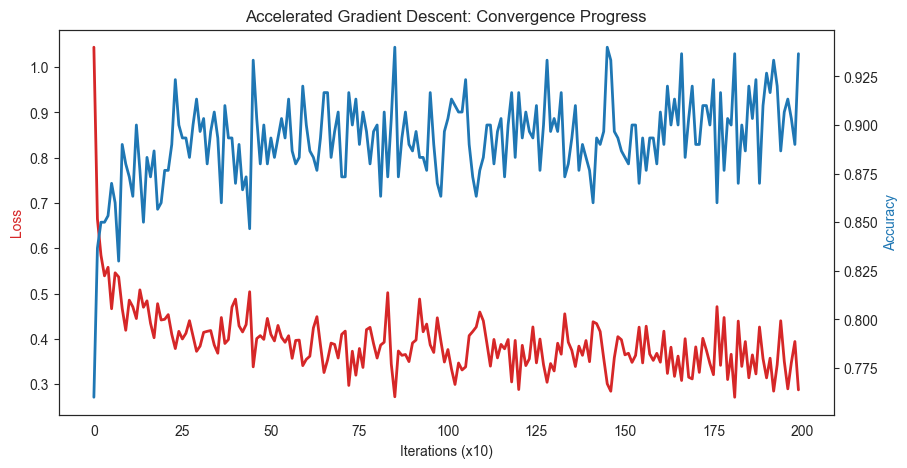

In [124]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Loss
ax1.plot(vec_loss, color='tab:red', label='Loss (Momentum)', linewidth=2)
ax1.set_ylabel('Loss', color='tab:red')
ax1.set_xlabel('Iterations (x10)')

# Plot Accuracy
ax2 = ax1.twinx()
ax2.plot(vec_acc, color='tab:blue', label='Accuracy (Momentum)', linewidth=2)
ax2.set_ylabel('Accuracy', color='tab:blue')

plt.title("Accelerated Gradient Descent: Convergence Progress")
plt.show()

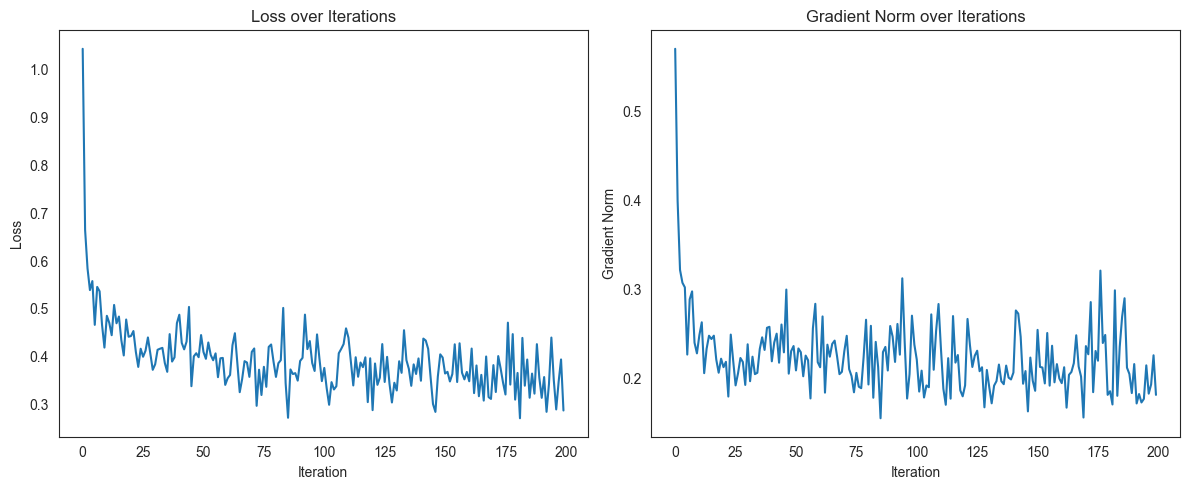

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(vec_loss)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over Iterations")

# Gradient norm plot
plt.subplot(1, 2, 2)
plt.plot(vec_grad_norm)
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm over Iterations")

plt.tight_layout()
plt.show()


In [126]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Metrics storage
history = {
    'GD': {'loss': [], 'grad_norm': []},
    'SGD': {'loss': [], 'grad_norm': []},
    'Accel': {'loss': [], 'grad_norm': []}
}

# --- 1. Standard Gradient Descent (MSE) ---
W_gd = np.zeros((x_train.shape[1], 10))
L = 2 * la.norm(x_train, 2)**2
alpha_gd = 2 / L

for i in range(500):
    grad = 2 * x_train.T @ (x_train @ W_gd - Y_train)
    W_gd -= alpha_gd * grad
    
    loss = la.norm(x_train @ W_gd - Y_train)**2
    history['GD']['loss'].append(loss)
    history['GD']['grad_norm'].append(la.norm(grad))

# --- 2. SGD & Accelerated SGD (Cross-Entropy) ---
methods = ['SGD', 'Accel']
for method in methods:
    W = np.zeros((m, 10))
    V = np.zeros((m, 10))
    gamma = 0.9 if method == 'Accel' else 0.0
    
    for k in range(1, 2001):
        alpha = 0.1 / np.sqrt(k)
        idx = np.random.permutation(n)[:batch]
        
        # Forward & Gradient
        logits = x_train[idx] @ W
        predictions = softmax(logits)
        grad = (1 / batch) * x_train[idx].T @ (predictions - Y_train[idx])
        
        # Update
        V = gamma * V + alpha * grad
        W = W - V
        
        if k % 10 == 0:
            loss = -np.mean(np.sum(Y_train[idx] * np.log(predictions + 1e-8), axis=1))
            history[method]['loss'].append(loss)
            history[method]['grad_norm'].append(la.norm(grad))

# --- 3. Evaluate Final Test Accuracy ---
def get_acc(W, X, Y):
    preds = np.argmax(X @ W, axis=1)
    true = np.argmax(Y, axis=1)
    return np.mean(preds == true) * 100

print(f"GD Test Accuracy: {get_acc(W_gd, x_test, Y_test):.2f}%")

GD Test Accuracy: 85.38%


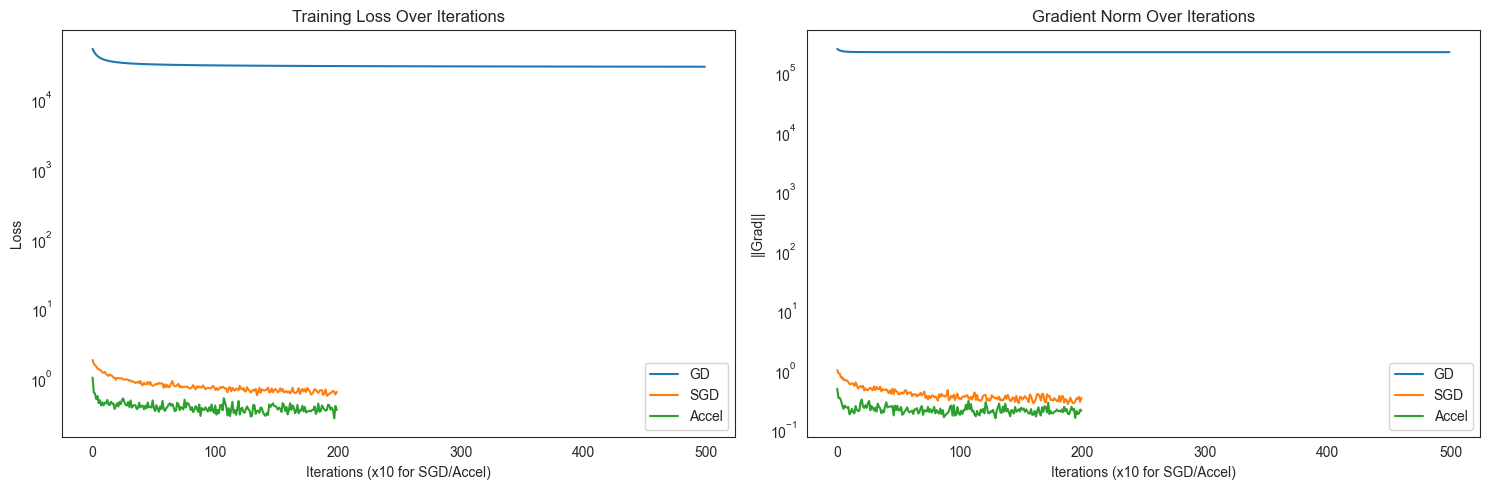

In [127]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
for label, data in history.items():
    ax1.plot(data['loss'], label=label)
ax1.set_title("Training Loss Over Iterations")
ax1.set_xlabel("Iterations (x10 for SGD/Accel)")
ax1.set_ylabel("Loss")
ax1.set_yscale('log') # Log scale helps see convergence
ax1.legend()

# Plot Gradient Norm
for label, data in history.items():
    ax2.plot(data['grad_norm'], label=label)
ax2.set_title("Gradient Norm Over Iterations")
ax2.set_xlabel("Iterations (x10 for SGD/Accel)")
ax2.set_ylabel("||Grad||")
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_92 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step - accuracy: 0.1160 - loss: 2.3844
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.1184 - loss: 2.3690
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.1203 - loss: 2.3547
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.1232 - loss: 2.3413
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.1259 - loss: 2.3287
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.1289 - loss: 2.3167
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.1318 - loss: 2.3054
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.1350 - loss: 2.2946
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1385 - loss: 2.2843
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.1423 - loss: 2.2745
GD Training Complete. Evaluating on test set...
GD Test Accuracy: 0.1473
GD Test Loss: 2.2645


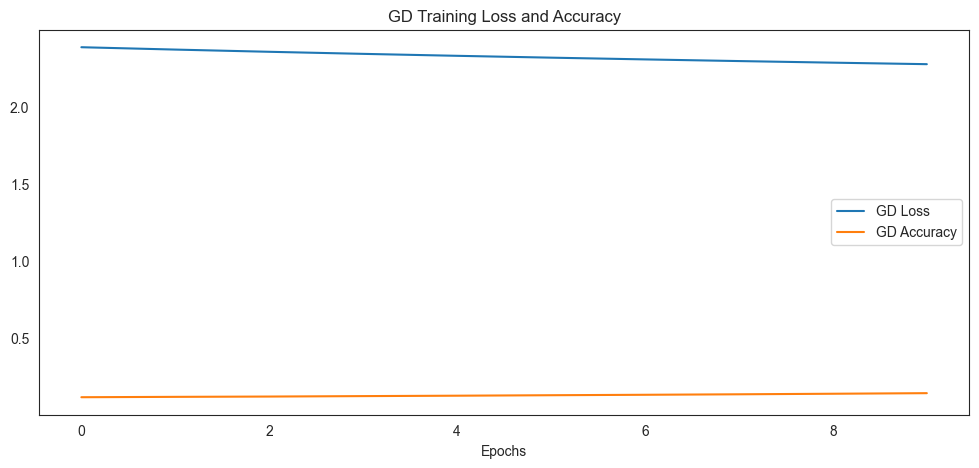

In [128]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
#To demonstrate different optimizers, we re-compile for each case:
# 1. Implementation for GD (Batch Gradient Descent)
# Use a batch size equal to the entire training set
optimizer_gd = keras.optimizers.SGD(learning_rate=0.01)
model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    
    layers.Dense(128, activation='relu',
                 kernel_initializer='he_uniform',
                 bias_initializer='zeros'),
    
    layers.Dense(64, activation='relu',
                 kernel_initializer='he_uniform',
                 bias_initializer='zeros'),
    
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer=optimizer_gd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Convert One-Hot vectors back to integer labels
Y_train_int = np.argmax(Y_train, axis=1)
model.summary()
history_gd = model.fit(x_train, Y_train_int, epochs=10, batch_size=len(x_train))
print("GD Training Complete. Evaluating on test set...")
test_loss_gd, test_acc_gd = model.evaluate(x_test, np.argmax(Y_test, axis=1), verbose=0)
print(f"GD Test Accuracy: {test_acc_gd:.4f}")
print(f"GD Test Loss: {test_loss_gd:.4f}")
plt.figure(figsize=(12,5))
plt.plot(history_gd.history['loss'], label='GD Loss')
plt.plot(history_gd.history['accuracy'], label='GD Accuracy')
plt.title("GD Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_92 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.9321 - loss: 0.2189
Epoch 2/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 84s 1ms/step - accuracy: 0.9672 - loss: 0.1073
Epoch 3/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 84s 1ms/step - accuracy: 0.9755 - loss: 0.0791
Epoch 4/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 83s 1ms/step - accuracy: 0.9800 - loss: 0.0624
Epoch 5/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 84s 1ms/step - accuracy: 0.9837 - loss: 0.0507
Epoch 6/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 84s 1ms/step - accuracy: 0.9856 - loss: 0.0444
Epoch 7/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 85s 1ms/step - accuracy: 0.9871 - loss: 0.0399
Epoch 8/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 89s 1ms/step - accuracy: 0.9895 - loss: 0.0333
Epoch 9/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 86s 1ms/step - accuracy: 0.9901 - loss: 0.0304
Epoch 10/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 87s 1ms/step - accuracy: 0.9912 - loss: 0.0287
SGD Training Complete. Evaluating on test set...
SGD Test Accuracy: 0.9739
SGD Test Loss:

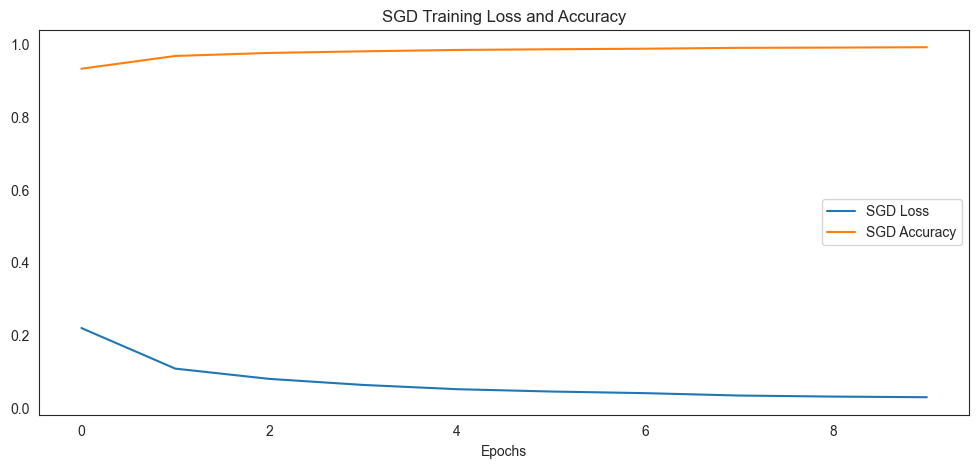

In [129]:
# 2. Implementation for SGD (Stochastic Gradient Descent)
# Use a batch size of 1
optimizer_sgd = keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=optimizer_sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Convert One-Hot vectors back to integer labels
Y_train_int = np.argmax(Y_train, axis=1)
model.summary()
history_sgd = model.fit(x_train, Y_train_int, epochs=10, batch_size=1)
print("SGD Training Complete. Evaluating on test set...")
test_loss_sgd, test_acc_sgd = model.evaluate(x_test
                                             , np.argmax(Y_test, axis=1), verbose=0)
print(f"SGD Test Accuracy: {test_acc_sgd:.4f}")
print(f"SGD Test Loss: {test_loss_sgd:.4f}")
plt.figure(figsize=(12,5))
plt.plot(history_sgd.history['loss'], label='SGD Loss')
plt.plot(history_sgd.history['accuracy'], label='SGD Accuracy')
plt.title("SGD Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()



Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9937 - loss: 0.0189
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9953 - loss: 0.0142
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9954 - loss: 0.0134
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9964 - loss: 0.0115
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9965 - loss: 0.0108
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9965 - loss: 0.0112
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9968 - loss: 0.0093
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9975 - loss: 0.0076
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9973 - loss: 0.0084
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9973 - loss: 0.0078
Adam Training Complete. Evaluating on test set...
Adam Test Accuracy: 0.9790
Adam Test Loss: 0.1242


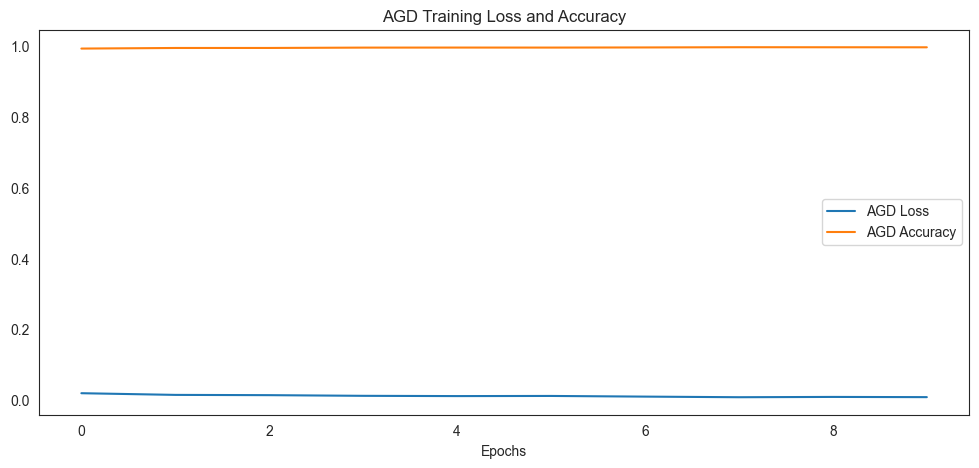

In [61]:
# 3. Implementation for AGD (Adaptive/Adam)
# This uses adaptive learning rates for each parameter
optimizer_adam = keras.optimizers.Adam(learning_rate=0.001)


model.compile(
    optimizer=optimizer_adam, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_adam = model.fit(x_train, Y_train_int, epochs=10, batch_size=32)
print("Adam Training Complete. Evaluating on test set...")
test_loss_adam, test_acc_adam = model.evaluate(x_test, np.argmax(Y_test, axis=1), verbose=0)
print(f"Adam Test Accuracy: {test_acc_adam:.4f}")
print(f"Adam Test Loss: {test_loss_adam:.4f}")

plt.figure(figsize=(12,5))
plt.plot(history_adam.history['loss'], label='AGD Loss')
plt.plot(history_adam.history['accuracy'], label='AGD Accuracy')
plt.title("AGD Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [131]:
#Adding L1-norm and L2-norm regularizations and compare the training and testing performance.

from keras import regularizers

#L1 Regularization
def create_model_l1():
    return keras.Sequential([
        layers.Input(shape=(num_features,)),
        
        layers.Dense(128, activation='relu',
                     kernel_initializer='he_uniform',
                     kernel_regularizer=regularizers.l1(1e-4)),
        
        layers.Dense(64, activation='relu',
                     kernel_initializer='he_uniform',
                     kernel_regularizer=regularizers.l1(1e-4)),
        
        layers.Dense(10, activation='softmax')
    ])

#L2 Regularization
def create_model_l2():
    return keras.Sequential([
        layers.Input(shape=(num_features,)),
        
        layers.Dense(128, activation='relu',
                     kernel_initializer='he_uniform',   
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(64, activation='relu',
                        kernel_initializer='he_uniform',
                        kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(10, activation='softmax')
    ])

#no regularization
def create_model_base():
    return keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(64, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(10, activation='softmax')
    ])
models = {
    "No Reg": create_model_base(),
    "L1": create_model_l1(),
    "L2": create_model_l2()
}

results_reg = {}

for name, model in models.items():
    print(f"\nTraining with {name}")
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        x_train,
        np.argmax(Y_train, axis=1),
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(
        x_test,
        np.argmax(Y_test, axis=1),
        verbose=0
    )
    
    results_reg[name] = {
        "history": history.history,
        "test_acc": test_acc
    }
    
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Test Loss: {test_loss:.4f}")




Training with No Reg
No Reg Test Accuracy: 0.9728
No Reg Test Loss: 0.1177

Training with L1
L1 Test Accuracy: 0.9717
L1 Test Loss: 0.2039

Training with L2
L2 Test Accuracy: 0.9786
L2 Test Loss: 0.1198


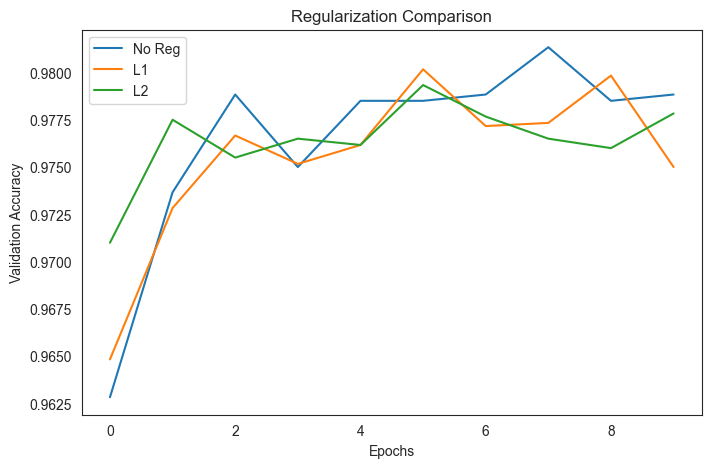

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for name in results_reg:
    plt.plot(results_reg[name]['history']['val_accuracy'], label=name)

plt.title("Regularization Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


In [62]:
#
#Studying the effect of network depth and width on the training and testing performance.

def build_model(depth, width, activation='relu'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(num_features,)))
    
    for _ in range(depth):
        model.add(layers.Dense(width, activation=activation))
    
    model.add(layers.Dense(10, activation='softmax'))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


In [133]:
#study the effect of depth while keeping width fixed at 64
depths = [1, 2, 3, 4]
fixed_width = 64
depth_results = {}

print("\n===== Depth Experiment =====")

for d in depths:
    print(f"\nTraining Depth = {d}")
    
    model = build_model(depth=d, width=fixed_width, activation='relu')
    
    history = model.fit(
        x_train, Y_train_int,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(x_test, Y_test_int, verbose=0)
    
    depth_results[d] = {
        'history': history.history,
        'test_acc': test_acc
    }
    
    print(f"Depth {d} -> Test Accuracy: {test_acc:.4f}")



===== Depth Experiment =====

Training Depth = 1
Depth 1 -> Test Accuracy: 0.9744

Training Depth = 2
Depth 2 -> Test Accuracy: 0.9741

Training Depth = 3
Depth 3 -> Test Accuracy: 0.9741

Training Depth = 4
Depth 4 -> Test Accuracy: 0.9763


In [134]:
#study the effect of width while keeping depth fixed at 2
widths = [32, 64, 128, 256]
fixed_depth = 2
width_results = {}

print("\n===== Width Experiment =====")

for w in widths:
    print(f"\nTraining Width = {w}")
    
    model = build_model(depth=fixed_depth, width=w, activation='relu')
    
    history = model.fit(
        x_train, Y_train_int,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(x_test, Y_test_int, verbose=0)
    
    width_results[w] = {
        'history': history.history,
        'test_acc': test_acc
    }
    
    print(f"Width {w} -> Test Accuracy: {test_acc:.4f}")



===== Width Experiment =====

Training Width = 32
Width 32 -> Test Accuracy: 0.9669

Training Width = 64
Width 64 -> Test Accuracy: 0.9719

Training Width = 128
Width 128 -> Test Accuracy: 0.9771

Training Width = 256
Width 256 -> Test Accuracy: 0.9801


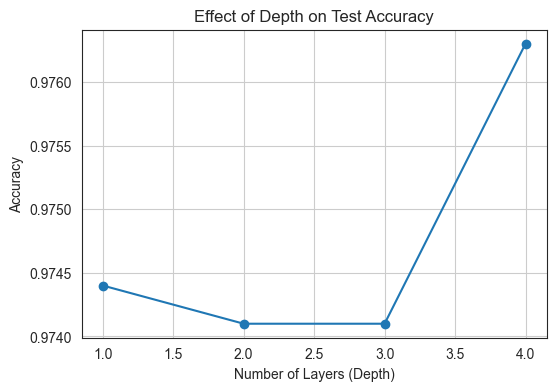

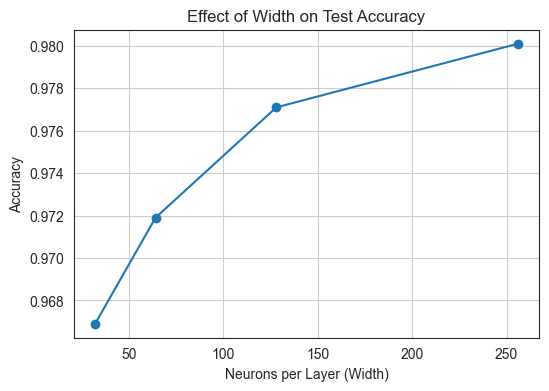

In [136]:
#depth plot

plt.figure(figsize=(6,4))
plt.plot(depths, [depth_results[d]['test_acc'] for d in depths], marker='o')
plt.title("Effect of Depth on Test Accuracy")
plt.xlabel("Number of Layers (Depth)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()
#width plot
plt.figure(figsize=(6,4))
plt.plot(widths, [width_results[w]['test_acc'] for w in widths], marker='o')
plt.title("Effect of Width on Test Accuracy")
plt.xlabel("Neurons per Layer (Width)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


In [137]:
model = build_model(depth=2, width=64, activation='relu')
history, test_acc, test_loss = train_model('relu')
print(f"ReLU -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
model = build_model(depth=2, width=64, activation='sigmoid')
history, test_acc, test_loss = train_model('sigmoid')   
print(f"Sigmoid -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")  
model = build_model(depth=2, width=64, activation='tanh')
history, test_acc, test_loss = train_model('tanh')
print(f"Tanh -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9263 - loss: 0.2504 - val_accuracy: 0.9618 - val_loss: 0.1342
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9667 - loss: 0.1103 - val_accuracy: 0.9735 - val_loss: 0.0869
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9764 - loss: 0.0768 - val_accuracy: 0.9755 - val_loss: 0.0826
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9815 - loss: 0.0578 - val_accuracy: 0.9740 - val_loss: 0.0792
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9857 - loss: 0.0443 - val_accuracy: 0.9730 - val_loss: 0.0903
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9881 - loss: 0.0362 - val_accuracy: 0.9782 - val_loss: 0.0747
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9898 - loss: 0.0305 - val_accuracy: 0.9783 - val_loss: 0.0799
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9917 - loss: 0.0256 - 

In [138]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()
nb_model.fit(x_train, Y_train_int)
y_pred_nb = nb_model.predict(x_test)
acc_nb = accuracy_score(Y_test_int, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)


Naive Bayes Accuracy: 0.5558


In [139]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(x_train, Y_train_int)

y_pred_rf = rf_model.predict(x_test)
acc_rf = accuracy_score(Y_test_int, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)


Random Forest Accuracy: 0.9704


In [140]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [141]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(x_train, Y_train_int)

y_pred_xgb = xgb_model.predict(x_test)
acc_xgb = accuracy_score(Y_test_int, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)


C:\Users\yashs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [18:39:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9705
